In [17]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import os
import time
import copy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision
from sklearn.metrics import roc_auc_score, confusion_matrix, matthews_corrcoef ,accuracy_score ,precision_score , recall_score ,f1_score,classification_report
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np



In [18]:
import os
import pandas as pd
Dataset_path = r"D:\__Projects\Graduation---Project\DL\Brain_Tumor\Data"
def load_data(dataset_path):
    data =[]
    labels =[]
    types =[]
    for split in os.listdir(dataset_path):
        split_path = os.path.join(dataset_path, split)
        if os.path.isdir(split_path):
            for label in os.listdir(split_path):
                label_path = os.path.join(split_path, label)
                if os.path.isdir(label_path):
                    for image_file in os.listdir(label_path):
                        image_path = os.path.join(label_path, image_file)
                        data.append(image_path)
                        labels.append(label)
                        types.append(split)  

    return pd.DataFrame({'image_path': data,'label': labels,'type': types})
df=load_data(Dataset_path)
df

,image_path,label,type
0,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
1,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
2,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
3,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
4,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
...,...,...,...
3259,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3260,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3261,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3262,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training


In [19]:
df.loc[df['type']=='Training', 'type']='train'
df.loc[df['type']=='Testing','type']="test"

In [20]:
df["label"].value_counts()

label
meningioma_tumor    937
glioma_tumor        926
pituitary_tumor     901
no_tumor            500
Name: count, dtype: int64

In [21]:
df.isna().sum()

image_path    0
label         0
type          0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df_train = df[df['type']=='train']
df_test = df[df['type']=='test']

label
pituitary_tumor     827
glioma_tumor        826
meningioma_tumor    822
no_tumor            395
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

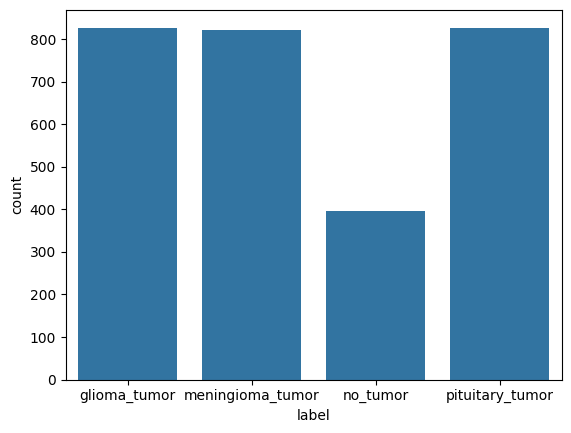

In [24]:
print(df_train['label'].value_counts())
sns.countplot(x='label', data=df_train)

label
meningioma_tumor    115
no_tumor            105
glioma_tumor        100
pituitary_tumor      74
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

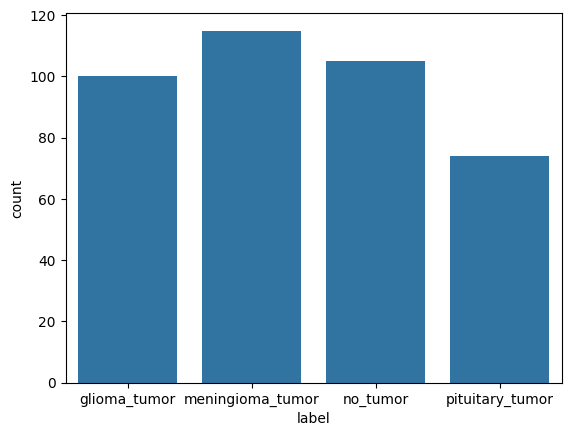

In [25]:
print(df_test['label'].value_counts())
sns.countplot(x='label', data=df_test)

In [26]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class Brain_TumorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df=df.copy()
        self.transform = transform
        self.df['label_idx']=self.df['label'].map({'meningioma_tumor': 0, 'no_tumor': 1, 'glioma_tumor': 2,"pituitary_tumor": 3}).astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return image, label

In [27]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df[df['type'] == 'train'],test_size=0.2,random_state=42,stratify=df[df['type']=="train"]['label'] )
test_df = df[df['type'] == 'test']
train_dataset= Brain_TumorDataset(train_df, transform=train_transform)
val_dataset= Brain_TumorDataset(val_df,   transform=val_transform)
test_dataset= Brain_TumorDataset(test_df,  transform=val_transform)
train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader= DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
test_loader= DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)


In [28]:
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# Model
# =====================
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 4)
)

model = model.to(device)

# =====================
# Class Weights (FIXED)
# =====================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# =====================
# Loss (FIXED - no overwrite)
# =====================
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# =====================
# Optimizer
# =====================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =====================
# Training Loop
# =====================
epochs = 25

for e in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    print(f"Epoch [{e+1}/{epochs}] | Training Loss: {epoch_loss:.4f}")

Epoch [1/25] | Training Loss: 0.9571
Epoch [2/25] | Training Loss: 0.7365
Epoch [3/25] | Training Loss: 0.6558
Epoch [4/25] | Training Loss: 0.6180
Epoch [5/25] | Training Loss: 0.6002
Epoch [6/25] | Training Loss: 0.5620
Epoch [7/25] | Training Loss: 0.5570
Epoch [8/25] | Training Loss: 0.5526
Epoch [9/25] | Training Loss: 0.5473
Epoch [10/25] | Training Loss: 0.5280
Epoch [11/25] | Training Loss: 0.5322
Epoch [12/25] | Training Loss: 0.5025
Epoch [13/25] | Training Loss: 0.5039
Epoch [14/25] | Training Loss: 0.5040
Epoch [15/25] | Training Loss: 0.5013
Epoch [16/25] | Training Loss: 0.4936
Epoch [17/25] | Training Loss: 0.4950
Epoch [18/25] | Training Loss: 0.4891
Epoch [19/25] | Training Loss: 0.4748
Epoch [20/25] | Training Loss: 0.4792
Epoch [21/25] | Training Loss: 0.4665
Epoch [22/25] | Training Loss: 0.4795
Epoch [23/25] | Training Loss: 0.4615
Epoch [24/25] | Training Loss: 0.4694
Epoch [25/25] | Training Loss: 0.4648


In [29]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

print("ResNet18 Results:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=['meningioma_tumor', 'no_tumor', 'glioma_tumor', 'pituitary_tumor']
))

ResNet18 Results:
Accuracy: 81.22%
Precision: 0.836 | Recall: 0.812 | F1: 0.809 | AUC: 0.922
                  precision    recall  f1-score   support

meningioma_tumor       0.71      0.94      0.81       115
        no_tumor       0.84      0.93      0.89       105
    glioma_tumor       0.86      0.65      0.74       100
 pituitary_tumor       1.00      0.66      0.80        74

        accuracy                           0.81       394
       macro avg       0.85      0.80      0.81       394
    weighted avg       0.84      0.81      0.81       394



In [30]:
torch.save(model.state_dict(), r"D:\__Projects\Graduation---Project\app\models\resnet18_brain_tumor.pth")

In [31]:
model = resnet18(weights=None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 4)
)
model.load_state_dict(torch.load(r"D:\__Projects\Graduation---Project\app\models\resnet18_brain_tumor.pth"))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def generate(self, input_image, class_idx=None):
        self.model.eval()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output).item()

        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Gradients or activations not captured")

        grads = self.gradients
        acts = self.activations

        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * acts, dim=1).squeeze().cpu().numpy()

        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam

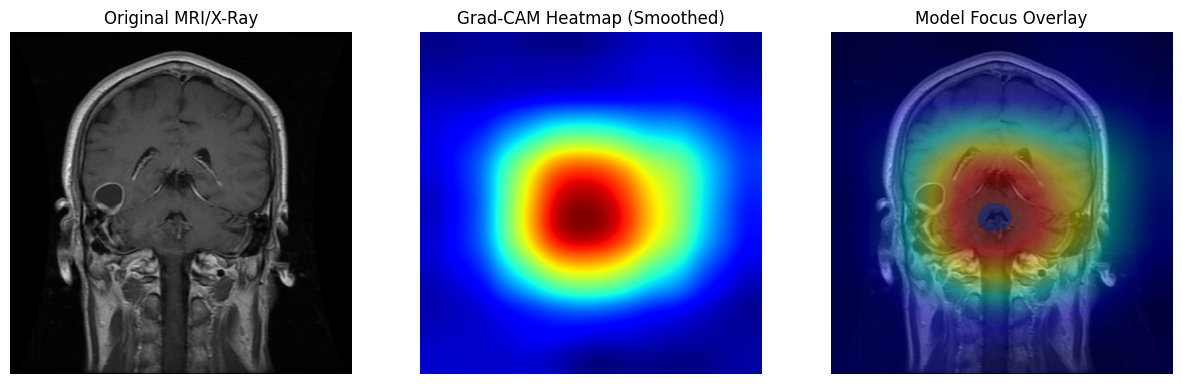

In [ ]:
s= test_df.iloc[60]
img_path=s['image_path']
img = Image.open(img_path).convert('RGB')
transform= val_transform
input_tensor= transform(img).unsqueeze(0).to(device)
target_layer= model.layer4[-1] 
gradcam= GradCAM(model, target_layer)
cam= gradcam.generate(input_tensor)

orig_width, orig_height = img.size 

cam_resized = cv2.resize(cam, (orig_width, orig_height), interpolation=cv2.INTER_CUBIC)

heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

img_np = np.array(img)
superimposed = cv2.addWeighted(heatmap, 0.4, img_np, 0.6, 0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Original MRI/X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap='jet')
plt.title("Grad-CAM Heatmap (Smoothed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title("Model Focus Overlay")
plt.axis('off')
plt.show()